<a href="https://colab.research.google.com/github/zoepallonigallo/esteganografia_steganography/blob/main/Steganography_LSB_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LSB Steganography and Basic Steganalysis
**By:** Zoe Palloni Gallo
**Field:** Cybersecurity / Digital Forensics

### What is this project about?
Steganography is the practice of concealing information within another file (like an image) without it being noticeable to the naked eye. Unlike cryptography (which makes the message unreadable), steganography hides the very **existence** of the message.

In this Google Colab notebook, we will explore:
1. **The Attack (Concealment):** How to use the LSB (Least Significant Bit) technique with Python to hide a secret message inside the pixels of an image.
2. **The Defense (Steganalysis):** How to use visual analysis tools and statistical tests ($\chi^2$) to attempt to detect the modification and reveal their limitations.

**Block 1, ATTACK:**

In [ ]:
from PIL import Image

def ocultar_mensaje(imagen_path, mensaje, salida_path):
    imagen = Image.open(imagen_path).convert('RGB')
    binario_mensaje = ''.join([format(ord(i), '08b') for i in mensaje]) + '1111111111111110'
    pixeles = list(imagen.getdata())
    nueva_lista = []
    mensaje_index = 0
    for pixel in pixeles:
        r, g, b = pixel[:3]
        if mensaje_index < len(binario_mensaje):
            r = (r & ~1) | int(binario_mensaje[mensaje_index])
            mensaje_index += 1
        if mensaje_index < len(binario_mensaje):
            g = (g & ~1) | int(binario_mensaje[mensaje_index])
            mensaje_index += 1
        if mensaje_index < len(binario_mensaje):
            b = (b & ~1) | int(binario_mensaje[mensaje_index])
            mensaje_index += 1
        nueva_lista.append((r, g, b))
    imagen_modificada = Image.new(imagen.mode, imagen.size)
    imagen_modificada.putdata(nueva_lista)
    imagen_modificada.save(salida_path)

ocultar_mensaje("kitty.jpg", "ESTEGANOGRAFIA", "oculto.png")

We use the **LSB (Least Significant Bit)** technique. This technique alters the last bit of each color channel (Red, Green, Blue) in the image's pixels. Since it is the least significant bit, the change in color is so minuscule ($\pm1$ out of 255) that the human eye cannot perceive it.

We upload the file, run the code, and an image with the attack already applied is downloaded as "oculto.png".

Below is the code that injects the secret word `"ESTEGANOGRAFIA"` into the `kitty.jpg` image.


ORIGINAL IMAGE
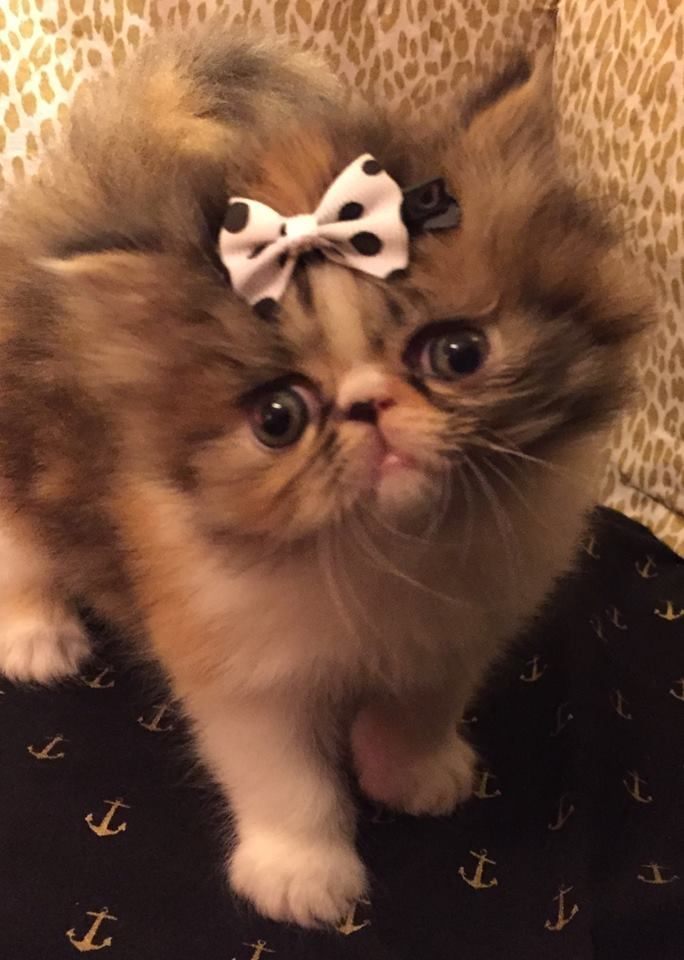

image with attack:
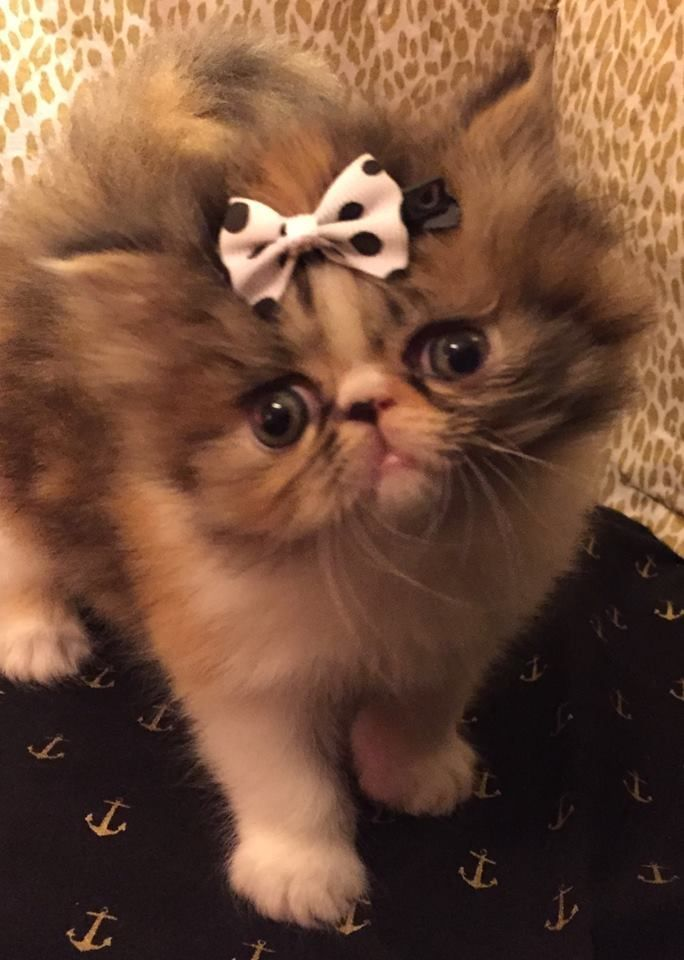

**Block 2, DEFENSE: Creating the Analysis Tools**

To attempt to detect if an image has been manipulated, we will create a Python script called `esteganalisis.py`. This script will act as our forensic tool with two main methods:

* **plano_lsb (Visual Analysis):** Extracts only the last bit of each pixel and displays it in black and white. If there is a message, we will see unnatural patterns.
* **chi_cuadrado (Statistical Analysis):** Applies the mathematical test $\chi^2$ to the image's histogram. If the value is very close to 0, it will confirm the presence of injected data.

In [ ]:
%%writefile esteganalisis.py

from __future__ import annotations
import sys
from pathlib import Path
from PIL import Image

def plano_lsb(entrada: Path, salida: Path) -> None:
    """Genera una imagen B/N con el LSB combinado de los tres canales (OR)."""
    img = Image.open(entrada).convert("RGB")
    w, h = img.size
    pix = list(img.getdata())
    nuevos = []
    for r, g, b in pix:
        v = ((r & 1) | (g & 1) | (b & 1)) * 255
        nuevos.append((v, v, v))
    out = Image.new("RGB", (w, h))
    out.putdata(nuevos)
    out.save(salida, format="PNG")
    print(f"OK · plano LSB guardado en {salida}")
    print(" · Foto natural → ruido aleatorio uniforme")
    print(" · Estegograma → estructuras visibles (bloques, texto, bordes)")

def chi_cuadrado(entrada: Path) -> None:
    """chi^2 sobre pares (2k, 2k+1) por cada canal RGB."""
    img = Image.open(entrada).convert("RGB")
    pix = list(img.getdata())
    for canal_idx, canal in enumerate("RGB"):
        hist = [0] * 256
        for p in pix:
            hist[p[canal_idx]] += 1
        chi = 0.0
        pares_validos = 0
        for k in range(128):
            n0, n1 = hist[2 * k], hist[2 * k + 1]
            esperado = (n0 + n1) / 2
            if esperado < 5: # criterio clásico para chi^2 fiable
                continue
            chi += (n0 - esperado) ** 2 / esperado
            pares_validos += 1

        veredicto = (
            "sospechoso de LSB" if chi < 50 and pares_validos > 50
            else "natural" if chi > 200
            else "indeterminado"
        )
        print(f"Canal {canal}: chi^2 = {chi:9.2f} (pares validos = {pares_validos:3d}) → {veredicto}")

def main() -> None:
    args = sys.argv[1:]
    if len(args) == 3 and args[0] == "plano_lsb":
        plano_lsb(Path(args[1]), Path(args[2]))
    elif len(args) == 2 and args[0] == "chi_cuadrado":
        chi_cuadrado(Path(args[1]))
    else:
        print(__doc__)
        sys.exit(1)

if __name__ == "__main__":
    main()

Overwriting esteganalisis.py


In [ ]:
!python esteganalisis.py plano_lsb oculto.png resultado_visual.png

OK · plano LSB guardado en resultado_visual.png
 · Foto natural → ruido aleatorio uniforme
 · Estegograma → estructuras visibles (bloques, texto, bordes)


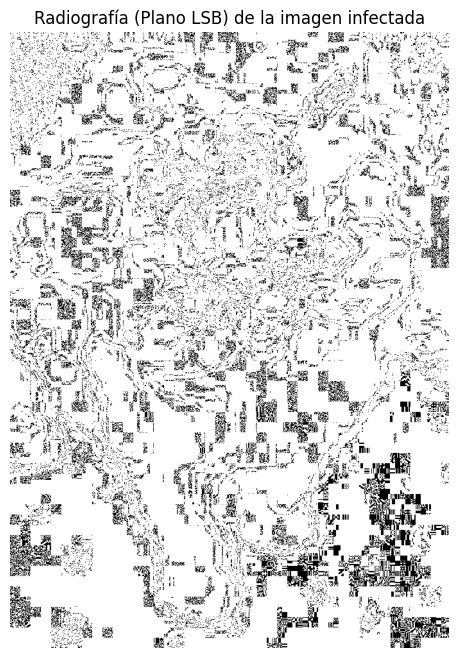

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Mostramos la "radiografía" en pantalla
imagen_radiografia = Image.open("resultado_visual.png")
plt.figure(figsize=(8, 8))
plt.imshow(imagen_radiografia)
plt.title("Radiografía (Plano LSB) de la imagen infectada")
plt.axis('off')
plt.show()

### Visual Analysis Conclusion

At first glance, the LSB plane looks like mere "static" or random noise. This is because we used a real photograph (with natural textures and shadows) and our message (`"ESTEGANOGRAFIA"`) is very short. The tiny alteration of the pixels is perfectly camouflaged in the natural noise of the image. The visual analysis **does not raise any obvious suspicions**.

Step 2: Statistical Analysis ($\chi^2$)Now we will pass the infected image through our mathematical scanner. The Chi-square test compares the frequency of colors. However, since the word "ESTEGANOGRAFIA" is very short, we will see if the math is capable of detecting this tiny alteration or if it confuses it with the natural noise of the photo.

In [ ]:
!python esteganalisis.py chi_cuadrado oculto.png

Canal R: chi^2 =   2559.53 (pares validos = 122) → natural
Canal G: chi^2 =   1897.82 (pares validos = 127) → natural
Canal B: chi^2 =   1662.31 (pares validos = 123) → natural


(Steganalysis Limitation)
As seen in the results above, the $\chi^2$ analysis did not detect the hidden text and classified the image as **"natural"**.

**The payload size problem:** Our secret word barely modified about 120 pixels in a high-resolution photo. The mathematical formula analyzes the entire image; seeing that such a microscopic amount of pixels changed, it assumes it is a natural variation or color noise from the camera.

The $\chi^2$ scanner is only truly effective when the image is heavily loaded with hidden information (generally when more than 10% or 15% of the available pixels are modified).